# Imports


In [ ]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler


drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/SmartCities')

df = pd.read_csv(BASE_DIR / 'berlin_pedestrians_2020_2024.csv')

print("Dataset loaded:", df.shape)
print("\nPedestrian accidents by year:")
print(df['YEAR'].value_counts().sort_index())

print("\nAvailable columns:")
print(df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (7931, 24)

Pedestrian accidents by year:
YEAR
2020    1396
2021    1460
2022    1569
2023    1794
2024    1712
Name: count, dtype: int64

Available columns:
['UJAHR', 'UMONAT', 'USTUNDE', 'UWOCHENTAG', 'UKATEGORIE', 'UART', 'UTYP1', 'ULICHTVERH', 'IstRad', 'IstPKW', 'IstFuss', 'IstKrad', 'IstGkfz', 'IstSonstige', 'LINREFX', 'LINREFY', 'XGCSWGS84', 'YGCSWGS84', 'YEAR', 'Severity', 'Lighting', 'Day', 'Month', 'Accident_Type']


# Analysis and Plots

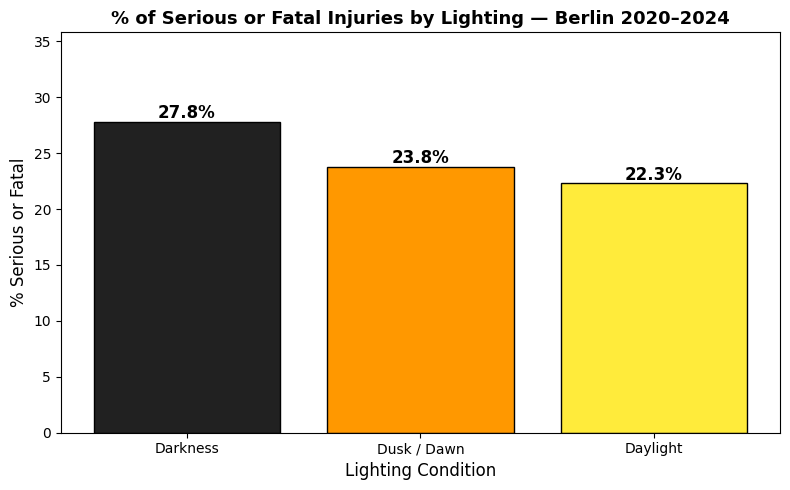


Key finding:
Lighting
Darkness       27.8
Dusk / Dawn    23.8
Daylight       22.3
Name: Severity, dtype: float64


In [ ]:
# Calculate percentage of serious+fatal per lighting condition
lighting_severity = df.groupby('Lighting')['Severity'].apply(
    lambda x: (x.isin(['Fatal', 'Serious Injury'])).sum() / len(x) * 100
).round(1)

lighting_severity = lighting_severity.sort_values(ascending=False)

colors = ['#212121', '#ff9800', '#ffeb3b']
plt.figure(figsize=(8, 5))
bars = plt.bar(lighting_severity.index, lighting_severity.values,
               color=colors, edgecolor='black')

for bar, val in zip(bars, lighting_severity.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.title('% of Serious or Fatal Injuries by Lighting — Berlin 2020–2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Lighting Condition', fontsize=12)
plt.ylabel('% Serious or Fatal', fontsize=12)
plt.ylim(0, max(lighting_severity.values) + 8)
plt.tight_layout()
plt.savefig('corr1_severity_rate_lighting.png', dpi=150)
plt.show()

print("\nKey finding:")
print(lighting_severity)

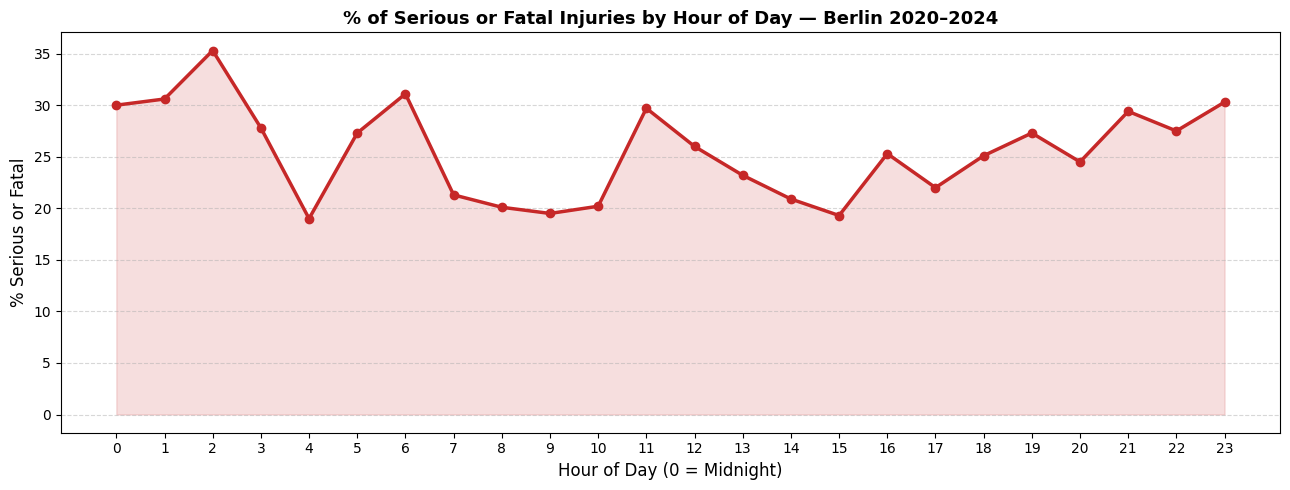


Most dangerous hours (highest serious/fatal rate):
USTUNDE
2     35.3
6     31.1
1     30.6
23    30.3
0     30.0
Name: Severity, dtype: float64


In [ ]:
hour_severity = df.groupby('USTUNDE')['Severity'].apply(
    lambda x: (x.isin(['Fatal', 'Serious Injury'])).sum() / len(x) * 100
).round(1)

plt.figure(figsize=(13, 5))
plt.plot(hour_severity.index, hour_severity.values,
         marker='o', color='#c62828', linewidth=2.5)
plt.fill_between(hour_severity.index, hour_severity.values,
                 alpha=0.15, color='#c62828')

plt.title('% of Serious or Fatal Injuries by Hour of Day — Berlin 2020–2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight)', fontsize=12)
plt.ylabel('% Serious or Fatal', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('corr2_severity_rate_hour.png', dpi=150)
plt.show()

print("\nMost dangerous hours (highest serious/fatal rate):")
print(hour_severity.sort_values(ascending=False).head(5))

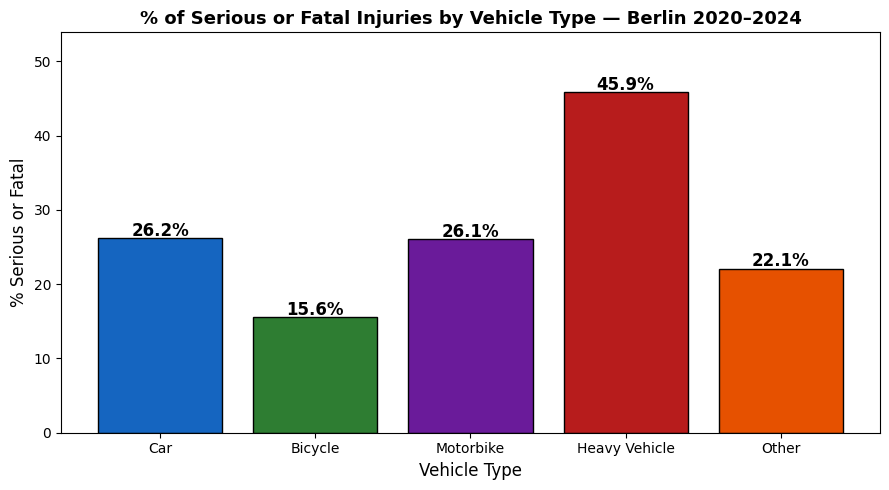


Key finding:
Car: 26.2%
Bicycle: 15.6%
Motorbike: 26.1%
Heavy Vehicle: 45.9%
Other: 22.1%


In [ ]:
vehicle_cols = {
    'Car': 'IstPKW',
    'Bicycle': 'IstRad',
    'Motorbike': 'IstKrad',
    'Heavy Vehicle': 'IstGkfz',
    'Other': 'IstSonstige'
}

vehicle_severity = {}
for label, col in vehicle_cols.items():
    involved = df[df[col] == 1]
    rate = (involved['Severity'].isin(['Fatal', 'Serious Injury'])).sum() / len(involved) * 100
    vehicle_severity[label] = round(rate, 1)

labels = list(vehicle_severity.keys())
values = list(vehicle_severity.values())

colors = ['#1565c0','#2e7d32','#6a1b9a','#b71c1c','#e65100']
plt.figure(figsize=(9, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.title('% of Serious or Fatal Injuries by Vehicle Type — Berlin 2020–2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('% Serious or Fatal', fontsize=12)
plt.ylim(0, max(values) + 8)
plt.tight_layout()
plt.savefig('corr3_severity_rate_vehicle.png', dpi=150)
plt.show()

print("\nKey finding:")
for k, v in vehicle_severity.items():
    print(f"{k}: {v}%")

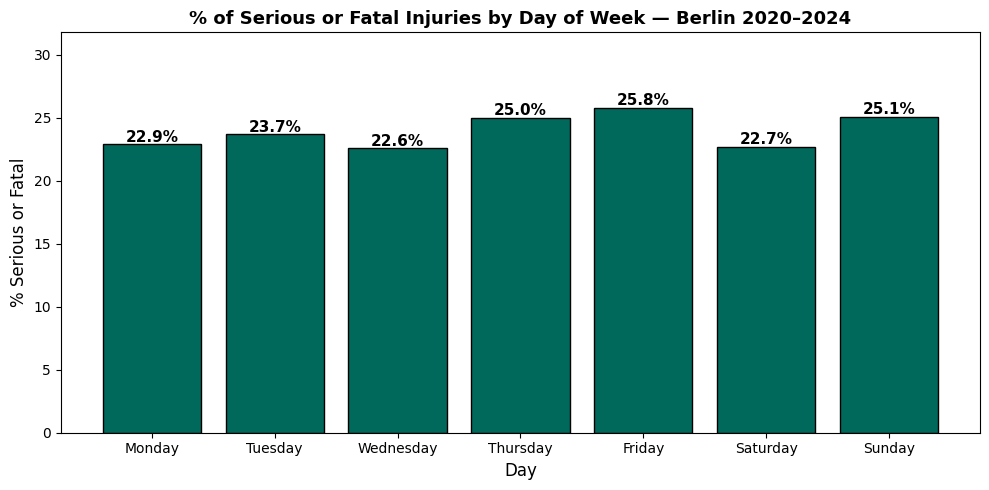


Key finding:
Day
Monday       22.9
Tuesday      23.7
Wednesday    22.6
Thursday     25.0
Friday       25.8
Saturday     22.7
Sunday       25.1
Name: Severity, dtype: float64


In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_severity = df.groupby('Day')['Severity'].apply(
    lambda x: (x.isin(['Fatal', 'Serious Injury'])).sum() / len(x) * 100
).round(1).reindex(day_order)

plt.figure(figsize=(10, 5))
bars = plt.bar(day_severity.index, day_severity.values,
               color='#00695c', edgecolor='black')

for bar, val in zip(bars, day_severity.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val}%', ha='center', fontweight='bold', fontsize=11)

plt.title('% of Serious or Fatal Injuries by Day of Week — Berlin 2020–2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('% Serious or Fatal', fontsize=12)
plt.ylim(0, max(day_severity.values) + 6)
plt.tight_layout()
plt.savefig('corr4_severity_rate_day.png', dpi=150)
plt.show()

print("\nKey finding:")
print(day_severity)

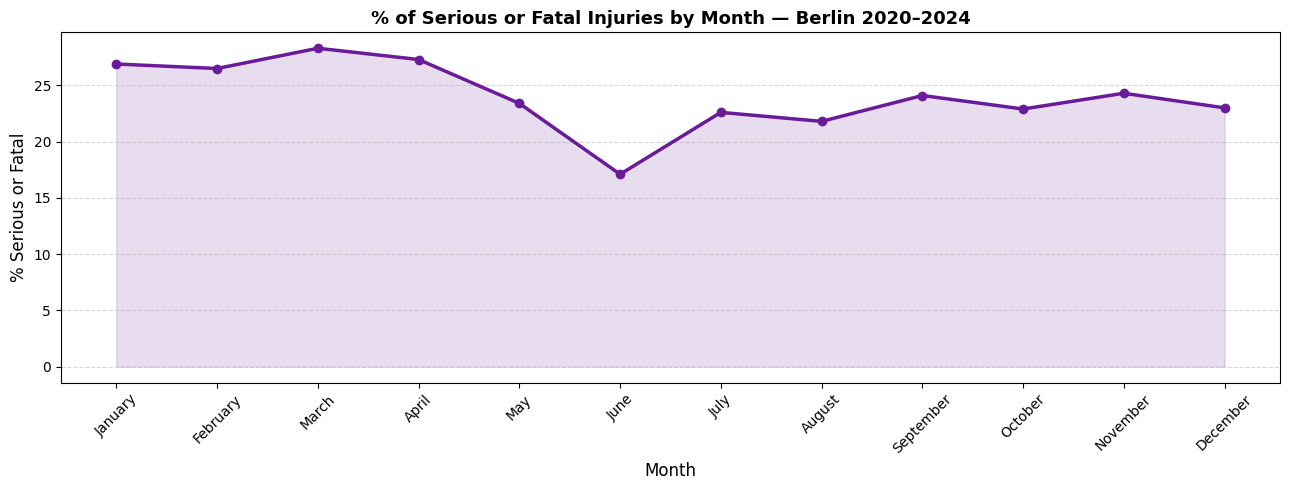


Most dangerous months:
Month
March       28.3
April       27.3
January     26.9
February    26.5
November    24.3
Name: Severity, dtype: float64


In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month_severity = df.groupby('Month')['Severity'].apply(
    lambda x: (x.isin(['Fatal', 'Serious Injury'])).sum() / len(x) * 100
).round(1).reindex(month_order)

plt.figure(figsize=(13, 5))
plt.plot(month_order, month_severity.values,
         marker='o', color='#6a1b9a', linewidth=2.5)
plt.fill_between(range(len(month_order)), month_severity.values,
                 alpha=0.15, color='#6a1b9a')

plt.title('% of Serious or Fatal Injuries by Month — Berlin 2020–2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('% Serious or Fatal', fontsize=12)
plt.xticks(range(len(month_order)), month_order, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('corr5_severity_rate_month.png', dpi=150)
plt.show()

print("\nMost dangerous months:")
print(month_severity.sort_values(ascending=False).head(5))

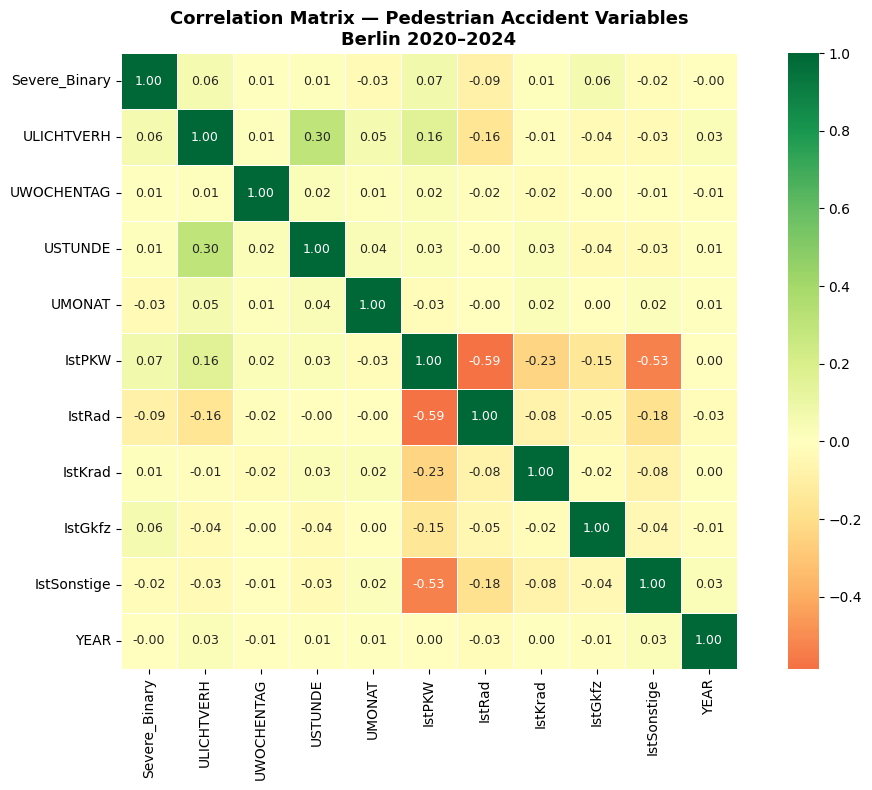


Correlations with Severity:
Severe_Binary    1.000000
IstPKW           0.072250
IstGkfz          0.060748
ULICHTVERH       0.056695
USTUNDE          0.013396
IstKrad          0.010058
UWOCHENTAG       0.006522
YEAR            -0.003176
IstSonstige     -0.017338
UMONAT          -0.030116
IstRad          -0.089585
Name: Severe_Binary, dtype: float64


In [ ]:
# Create binary severity column — 1 = serious/fatal, 0 = minor
df['Severe_Binary'] = df['Severity'].isin(['Fatal', 'Serious Injury']).astype(int)

# Select numerical variables for correlation
corr_cols = ['Severe_Binary', 'ULICHTVERH', 'UWOCHENTAG',
             'USTUNDE', 'UMONAT', 'IstPKW', 'IstRad',
             'IstKrad', 'IstGkfz', 'IstSonstige', 'YEAR']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Correlation Matrix — Pedestrian Accident Variables\nBerlin 2020–2024',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('corr6_heatmap.png', dpi=150)
plt.show()

print("\nCorrelations with Severity:")
print(corr_matrix['Severe_Binary'].sort_values(ascending=False))

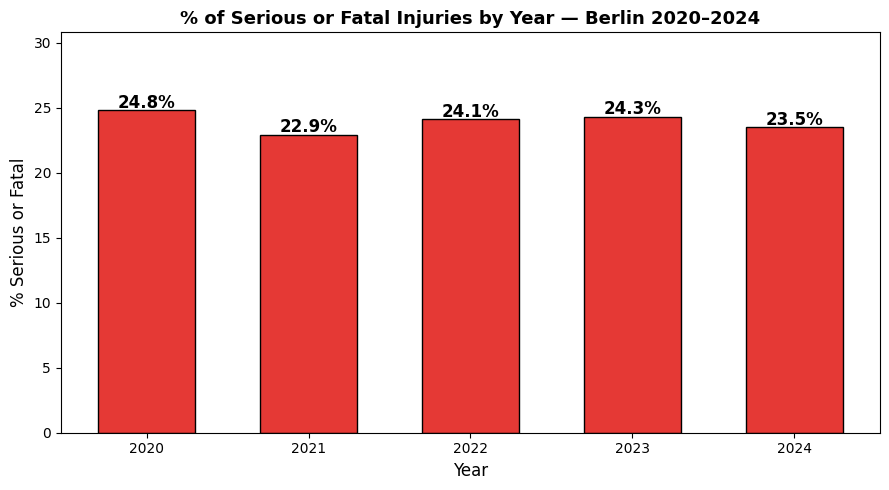


Severity rate by year:
YEAR
2020    24.8
2021    22.9
2022    24.1
2023    24.3
2024    23.5
Name: Severity, dtype: float64


In [ ]:
year_severity = df.groupby('YEAR')['Severity'].apply(
    lambda x: (x.isin(['Fatal', 'Serious Injury'])).sum() / len(x) * 100
).round(1)

plt.figure(figsize=(9, 5))
bars = plt.bar(year_severity.index, year_severity.values,
               color='#e53935', edgecolor='black', width=0.6)

for bar, val in zip(bars, year_severity.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.title('% of Serious or Fatal Injuries by Year — Berlin 2020–2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('% Serious or Fatal', fontsize=12)
plt.xticks(year_severity.index)
plt.ylim(0, max(year_severity.values) + 6)
plt.tight_layout()
plt.savefig('corr7_severity_trend_year.png', dpi=150)
plt.show()

print("\nSeverity rate by year:")
print(year_severity)

In [ ]:
hotspot_df = df.copy()

# Convert coordinate columns to numeric if needed
def to_numeric_coord(series):
    return (
        series.astype(str)
        .str.replace(',', '.', regex=False)
        .str.strip()
        .str.rstrip('.')
        .replace('nan', np.nan)
        .astype(float)
    )

hotspot_df['XGCSWGS84'] = to_numeric_coord(hotspot_df['XGCSWGS84'])
hotspot_df['YGCSWGS84'] = to_numeric_coord(hotspot_df['YGCSWGS84'])

# Remove rows without valid coordinates
hotspot_df = hotspot_df.dropna(subset=['XGCSWGS84', 'YGCSWGS84']).copy()

# Create severe binary variable:
# 1 = Fatal or Serious Injury
# 0 = Minor/Slight Injury
hotspot_df['Severe_Binary'] = hotspot_df['UKATEGORIE'].apply(lambda x: 1 if x in [1, 2] else 0)

# Low-light and darkness indicators
hotspot_df['Low_Light'] = hotspot_df['ULICHTVERH'].apply(lambda x: 1 if x in [1, 2] else 0)
hotspot_df['Darkness'] = hotspot_df['ULICHTVERH'].apply(lambda x: 1 if x == 2 else 0)

print("Hotspot dataset ready:", hotspot_df.shape)
print("Total severe/fatal accidents:", hotspot_df['Severe_Binary'].sum())
print("Share severe/fatal:", round(hotspot_df['Severe_Binary'].mean() * 100, 2), "%")

Hotspot dataset ready: (7931, 27)
Total severe/fatal accidents: 1897
Share severe/fatal: 23.92 %


In [ ]:
# Install spatial libraries if needed
try:
    import geopandas as gpd
    from shapely.geometry import box
except ImportError:
    !pip install geopandas shapely -q
    import geopandas as gpd
    from shapely.geometry import box

# Create GeoDataFrame from accident coordinates
gdf = gpd.GeoDataFrame(
    hotspot_df,
    geometry=gpd.points_from_xy(hotspot_df['XGCSWGS84'], hotspot_df['YGCSWGS84']),
    crs='EPSG:4326'
)

# Project to metric CRS suitable for Berlin / Germany
gdf = gdf.to_crs('EPSG:25833')

# Create 500m x 500m grid based on accident data extent
xmin, ymin, xmax, ymax = gdf.total_bounds
cell_size = 500  # meters

grid_cells = []
grid_id = 0

x_coords = np.arange(xmin, xmax + cell_size, cell_size)
y_coords = np.arange(ymin, ymax + cell_size, cell_size)

for x0 in x_coords:
    for y0 in y_coords:
        x1 = x0 + cell_size
        y1 = y0 + cell_size
        grid_cells.append({
            'grid_id': grid_id,
            'geometry': box(x0, y0, x1, y1)
        })
        grid_id += 1

grid = gpd.GeoDataFrame(grid_cells, crs='EPSG:25833')

print("Number of grid cells:", len(grid))
print("Number of accident points:", len(gdf))

Number of grid cells: 5394
Number of accident points: 7931


In [ ]:
# Spatial join: assign each accident to a 500m grid cell
joined = gpd.sjoin(
    gdf,
    grid[['grid_id', 'geometry']],
    how='left',
    predicate='within'
)

# Aggregate accident characteristics by grid cell
grid_summary = (
    joined.groupby('grid_id')
    .agg(
        total_accidents=('UKATEGORIE', 'count'),
        severe_accidents=('Severe_Binary', 'sum'),
        fatal_accidents=('UKATEGORIE', lambda x: (x == 1).sum()),
        serious_accidents=('UKATEGORIE', lambda x: (x == 2).sum()),
        minor_accidents=('UKATEGORIE', lambda x: (x == 3).sum()),
        dark_accidents=('Darkness', 'sum'),
        low_light_accidents=('Low_Light', 'sum'),
        heavy_vehicle_accidents=('IstGkfz', 'sum'),
        car_accidents=('IstPKW', 'sum'),
        bicycle_accidents=('IstRad', 'sum'),
        motorcycle_accidents=('IstKrad', 'sum'),
        other_mode_accidents=('IstSonstige', 'sum')
    )
    .reset_index()
)

# Merge summary back to grid
grid_hotspots = grid.merge(grid_summary, on='grid_id', how='left')

# Fill cells with no accidents
count_cols = [
    'total_accidents', 'severe_accidents', 'fatal_accidents', 'serious_accidents',
    'minor_accidents', 'dark_accidents', 'low_light_accidents',
    'heavy_vehicle_accidents', 'car_accidents', 'bicycle_accidents',
    'motorcycle_accidents', 'other_mode_accidents'
]

for col in count_cols:
    grid_hotspots[col] = grid_hotspots[col].fillna(0).astype(int)

# Calculate shares
grid_hotspots['severe_rate'] = grid_hotspots['severe_accidents'] / grid_hotspots['total_accidents'].replace(0, np.nan)
grid_hotspots['dark_share'] = grid_hotspots['dark_accidents'] / grid_hotspots['total_accidents'].replace(0, np.nan)
grid_hotspots['low_light_share'] = grid_hotspots['low_light_accidents'] / grid_hotspots['total_accidents'].replace(0, np.nan)
grid_hotspots['heavy_vehicle_share'] = grid_hotspots['heavy_vehicle_accidents'] / grid_hotspots['total_accidents'].replace(0, np.nan)
grid_hotspots['car_share'] = grid_hotspots['car_accidents'] / grid_hotspots['total_accidents'].replace(0, np.nan)
grid_hotspots['bicycle_share'] = grid_hotspots['bicycle_accidents'] / grid_hotspots['total_accidents'].replace(0, np.nan)
grid_hotspots['motorcycle_share'] = grid_hotspots['motorcycle_accidents'] / grid_hotspots['total_accidents'].replace(0, np.nan)

# Keep only grid cells with accidents for ranking
grid_with_accidents = grid_hotspots[grid_hotspots['total_accidents'] > 0].copy()

print("Grid cells with at least one accident:", len(grid_with_accidents))
display(grid_with_accidents.sort_values('total_accidents', ascending=False).head(10))

Grid cells with at least one accident: 1602


,grid_id,geometry,total_accidents,severe_accidents,fatal_accidents,serious_accidents,minor_accidents,dark_accidents,low_light_accidents,heavy_vehicle_accidents,...,bicycle_accidents,motorcycle_accidents,other_mode_accidents,severe_rate,dark_share,low_light_share,heavy_vehicle_share,car_share,bicycle_share,motorcycle_share
779,779,"POLYGON ((377901.327 5821629.617, 377901.327 5...",50,16,1,15,34,12,18,0,...,6,0,13,0.320000,0.240000,0.360000,0.000000,0.640000,0.120000,0.000000
2751,2751,"POLYGON ((393901.327 5815629.617, 393901.327 5...",40,9,0,9,31,9,12,0,...,7,5,4,0.225000,0.225000,0.300000,0.000000,0.625000,0.175000,0.125000
2203,2203,"POLYGON ((389401.327 5820629.617, 389401.327 5...",35,3,0,3,32,16,17,0,...,9,0,9,0.085714,0.457143,0.485714,0.000000,0.514286,0.257143,0.000000
2333,2333,"POLYGON ((390401.327 5823629.617, 390401.327 5...",35,8,0,8,27,14,17,0,...,6,3,3,0.228571,0.400000,0.485714,0.000000,0.657143,0.171429,0.085714
2880,2880,"POLYGON ((394901.327 5818129.617, 394901.327 5...",34,5,1,4,29,9,14,0,...,25,1,4,0.147059,0.264706,0.411765,0.000000,0.147059,0.735294,0.029412
2512,2512,"POLYGON ((391901.327 5820129.617, 391901.327 5...",33,6,0,6,27,10,11,0,...,8,0,7,0.181818,0.303030,0.333333,0.000000,0.545455,0.242424,0.000000
2690,2690,"POLYGON ((393401.327 5816129.617, 393401.327 5...",31,6,0,6,25,11,15,0,...,9,1,8,0.193548,0.354839,0.483871,0.000000,0.483871,0.290323,0.032258
3068,3068,"POLYGON ((396401.327 5819129.617, 396401.327 5...",31,5,0,5,26,5,6,1,...,10,2,7,0.161290,0.161290,0.193548,0.032258,0.419355,0.322581,0.064516
1902,1902,"POLYGON ((386901.327 5825129.617, 386901.327 5...",31,10,0,10,21,2,3,0,...,3,2,3,0.322581,0.064516,0.096774,0.000000,0.774194,0.096774,0.064516
2693,2693,"POLYGON ((393401.327 5817629.617, 393401.327 5...",31,6,0,6,25,10,12,0,...,9,1,7,0.193548,0.322581,0.387097,0.000000,0.483871,0.290323,0.032258


In [ ]:
top_hotspots = (
    grid_with_accidents
    .sort_values('total_accidents', ascending=False)
    .head(10)
    .copy()
)

top_hotspots_table = top_hotspots[[
    'grid_id',
    'total_accidents',
    'severe_accidents',
    'fatal_accidents',
    'serious_accidents',
    'severe_rate',
    'dark_share',
    'heavy_vehicle_share',
    'car_share',
    'bicycle_share',
    'motorcycle_share'
]].copy()

# Convert shares to percentages for readability
percentage_cols = ['severe_rate', 'dark_share', 'heavy_vehicle_share', 'car_share', 'bicycle_share', 'motorcycle_share']

for col in percentage_cols:
    top_hotspots_table[col] = (top_hotspots_table[col] * 100).round(2)

display(top_hotspots_table)

top_hotspots_table.to_csv('top_10_grid_hotspots.csv', index=False)
print("Saved top_10_grid_hotspots.csv")

,grid_id,total_accidents,severe_accidents,fatal_accidents,serious_accidents,severe_rate,dark_share,heavy_vehicle_share,car_share,bicycle_share,motorcycle_share
779,779,50,16,1,15,32.00,24.00,0.00,64.00,12.00,0.00
2751,2751,40,9,0,9,22.50,22.50,0.00,62.50,17.50,12.50
2203,2203,35,3,0,3,8.57,45.71,0.00,51.43,25.71,0.00
2333,2333,35,8,0,8,22.86,40.00,0.00,65.71,17.14,8.57
2880,2880,34,5,1,4,14.71,26.47,0.00,14.71,73.53,2.94
2512,2512,33,6,0,6,18.18,30.30,0.00,54.55,24.24,0.00
2690,2690,31,6,0,6,19.35,35.48,0.00,48.39,29.03,3.23
3068,3068,31,5,0,5,16.13,16.13,3.23,41.94,32.26,6.45
1902,1902,31,10,0,10,32.26,6.45,0.00,77.42,9.68,6.45
2693,2693,31,6,0,6,19.35,32.26,0.00,48.39,29.03,3.23


Saved top_10_grid_hotspots.csv


In [ ]:
top_severe_hotspots = (
    grid_with_accidents
    .sort_values('severe_accidents', ascending=False)
    .head(10)
    .copy()
)

top_severe_table = top_severe_hotspots[[
    'grid_id',
    'total_accidents',
    'severe_accidents',
    'fatal_accidents',
    'serious_accidents',
    'severe_rate',
    'dark_share',
    'heavy_vehicle_share',
    'car_share',
    'bicycle_share',
    'motorcycle_share'
]].copy()

for col in percentage_cols:
    top_severe_table[col] = (top_severe_table[col] * 100).round(2)

display(top_severe_table)

top_severe_table.to_csv('top_10_severe_grid_hotspots.csv', index=False)
print("Saved top_10_severe_grid_hotspots.csv")

,grid_id,total_accidents,severe_accidents,fatal_accidents,serious_accidents,severe_rate,dark_share,heavy_vehicle_share,car_share,bicycle_share,motorcycle_share
779,779,50,16,1,15,32.00,24.00,0.00,64.00,12.00,0.00
1902,1902,31,10,0,10,32.26,6.45,0.00,77.42,9.68,6.45
2826,2826,22,10,2,8,45.45,18.18,0.00,27.27,27.27,9.09
2751,2751,40,9,0,9,22.50,22.50,0.00,62.50,17.50,12.50
2889,2889,16,9,0,9,56.25,37.50,12.50,68.75,12.50,0.00
2631,2631,31,8,1,7,25.81,51.61,0.00,61.29,19.35,6.45
2935,2935,24,8,0,8,33.33,29.17,4.17,70.83,16.67,0.00
2689,2689,27,8,1,7,29.63,55.56,0.00,59.26,14.81,18.52
2333,2333,35,8,0,8,22.86,40.00,0.00,65.71,17.14,8.57
2272,2272,27,8,0,8,29.63,44.44,0.00,70.37,0.00,3.70


Saved top_10_severe_grid_hotspots.csv


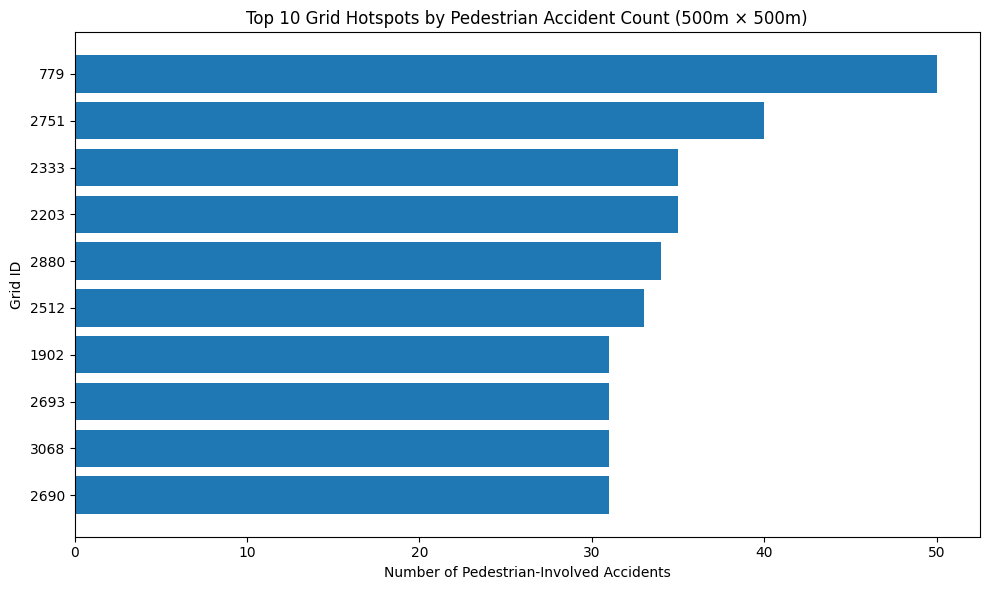

Saved chart_top_10_grid_hotspots.png


In [ ]:
import matplotlib.pyplot as plt

plot_data = top_hotspots_table.sort_values('total_accidents', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_data['grid_id'].astype(str), plot_data['total_accidents'])
plt.xlabel('Number of Pedestrian-Involved Accidents')
plt.ylabel('Grid ID')
plt.title('Top 10 Grid Hotspots by Pedestrian Accident Count (500m × 500m)')
plt.tight_layout()
plt.savefig('chart_top_10_grid_hotspots.png', dpi=150)
plt.show()

print("Saved chart_top_10_grid_hotspots.png")

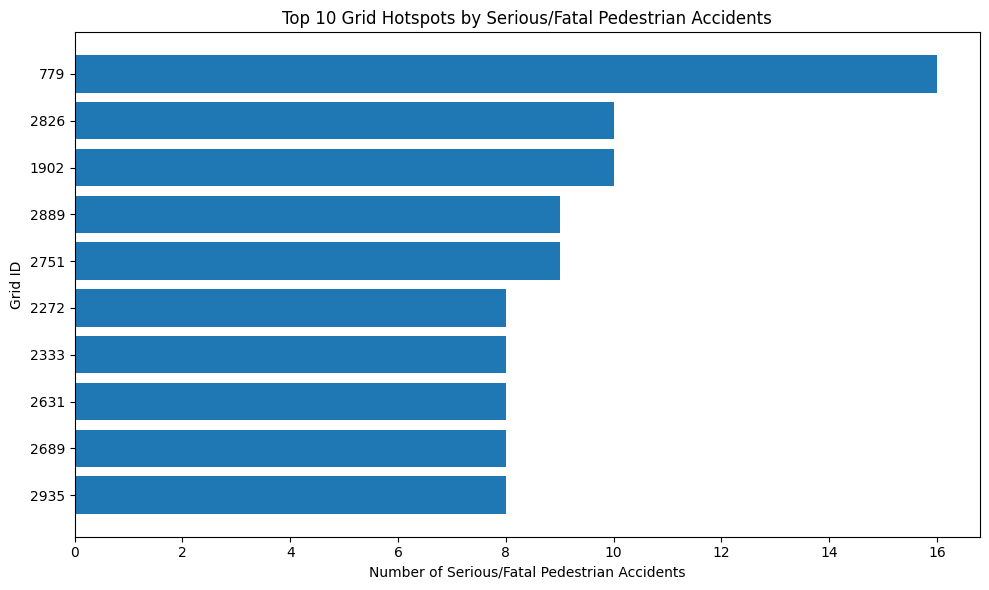

Saved chart_top_10_severe_grid_hotspots.png


In [ ]:
plot_data = top_severe_table.sort_values('severe_accidents', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_data['grid_id'].astype(str), plot_data['severe_accidents'])
plt.xlabel('Number of Serious/Fatal Pedestrian Accidents')
plt.ylabel('Grid ID')
plt.title('Top 10 Grid Hotspots by Serious/Fatal Pedestrian Accidents')
plt.tight_layout()
plt.savefig('chart_top_10_severe_grid_hotspots.png', dpi=150)
plt.show()

print("Saved chart_top_10_severe_grid_hotspots.png")

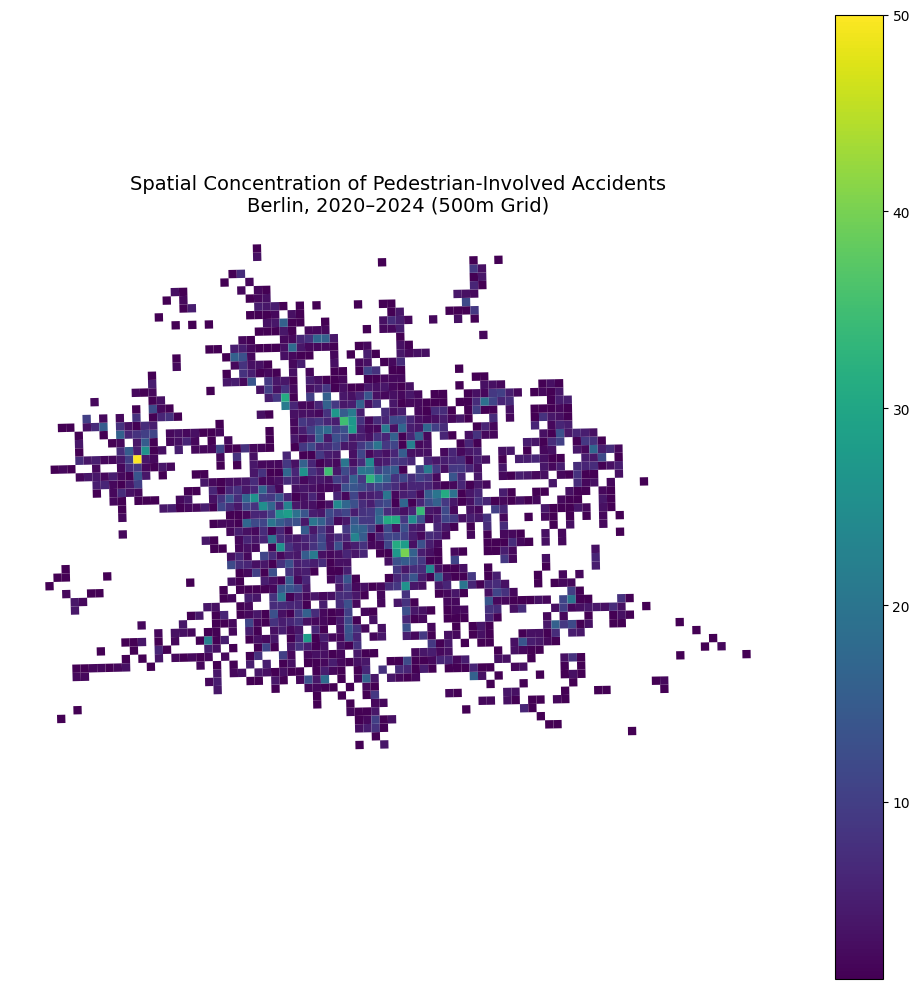

Saved map_grid_accident_concentration.png


In [ ]:
grid_plot = grid_hotspots.to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 10))

grid_plot[grid_plot['total_accidents'] > 0].plot(
    column='total_accidents',
    ax=ax,
    legend=True,
    edgecolor='none'
)

ax.set_title('Spatial Concentration of Pedestrian-Involved Accidents\nBerlin, 2020–2024 (500m Grid)', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('map_grid_accident_concentration.png', dpi=150)
plt.show()

print("Saved map_grid_accident_concentration.png")

In [ ]:
# Select top 10 grids by total accident count
top_grid_ids = top_hotspots['grid_id'].tolist()

hotspot_accidents = joined[joined['grid_id'].isin(top_grid_ids)].copy()
non_hotspot_accidents = joined[~joined['grid_id'].isin(top_grid_ids)].copy()

def profile_accidents(data, label):
    return {
        'area_type': label,
        'total_accidents': len(data),
        'severe_rate_percent': round(data['Severe_Binary'].mean() * 100, 2),
        'dark_share_percent': round(data['Darkness'].mean() * 100, 2),
        'low_light_share_percent': round(data['Low_Light'].mean() * 100, 2),
        'heavy_vehicle_share_percent': round(data['IstGkfz'].mean() * 100, 2),
        'car_share_percent': round(data['IstPKW'].mean() * 100, 2),
        'bicycle_share_percent': round(data['IstRad'].mean() * 100, 2),
        'motorcycle_share_percent': round(data['IstKrad'].mean() * 100, 2)
    }

hotspot_profile = pd.DataFrame([
    profile_accidents(hotspot_accidents, 'Top 10 accident hotspot grids'),
    profile_accidents(non_hotspot_accidents, 'All other grids')
])

display(hotspot_profile)

hotspot_profile.to_csv('hotspot_vs_non_hotspot_profile.csv', index=False)
print("Saved hotspot_vs_non_hotspot_profile.csv")

,area_type,total_accidents,severe_rate_percent,dark_share_percent,low_light_share_percent,heavy_vehicle_share_percent,car_share_percent,bicycle_share_percent,motorcycle_share_percent
0,Top 10 accident hotspot grids,351,21.08,27.92,35.61,0.28,53.56,26.21,4.27
1,All other grids,7580,24.05,27.90,34.70,1.42,65.44,17.04,3.69


Saved hotspot_vs_non_hotspot_profile.csv


In [ ]:
# Most common hours in hotspot areas
hotspot_hour_profile = (
    hotspot_accidents.groupby('USTUNDE')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='accident_count')
)

print("Most common accident hours in top hotspot grids:")
display(hotspot_hour_profile.head(10))

# Most common weekdays in hotspot areas
hotspot_day_profile = (
    hotspot_accidents.groupby('UWOCHENTAG')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='accident_count')
)

print("Most common weekdays in top hotspot grids:")
display(hotspot_day_profile.head(10))

# Most common accident types if available
if 'Accident_Type' in hotspot_accidents.columns:
    hotspot_type_profile = (
        hotspot_accidents.groupby('Accident_Type')
        .size()
        .sort_values(ascending=False)
        .reset_index(name='accident_count')
    )

    print("Most common accident types in top hotspot grids:")
    display(hotspot_type_profile.head(10))

Most common accident hours in top hotspot grids:


,USTUNDE,accident_count
0,16,34
1,17,31
2,18,31
3,14,23
4,15,23
5,19,22
6,13,21
7,20,19
8,8,18
9,11,18


Most common weekdays in top hotspot grids:


,UWOCHENTAG,accident_count
0,3,65
1,6,62
2,5,55
3,4,53
4,2,52
5,7,41
6,1,23


Most common accident types in top hotspot grids:


,Accident_Type,accident_count
0,Crossing accident,206
1,Stationary vehicle accident,75
2,Turning accident,63
3,Longitudinal accident,5
4,Turning/Crossing accident,2


In [ ]:
# Save grid hotspot summary as GeoJSON
grid_hotspots_wgs84 = grid_hotspots.to_crs('EPSG:4326')

grid_hotspots_wgs84.to_file('grid_hotspots_500m.geojson', driver='GeoJSON')

# Also save non-spatial table
grid_hotspots_wgs84.drop(columns='geometry').to_csv('grid_hotspots_500m_summary.csv', index=False)

print("Saved grid_hotspots_500m.geojson")
print("Saved grid_hotspots_500m_summary.csv")

Saved grid_hotspots_500m.geojson
Saved grid_hotspots_500m_summary.csv


In [ ]:
#  Make sure Severe_Binary exists
if 'Severe_Binary' not in df.columns:
    df['Severe_Binary'] = df['Severity'].isin(['Fatal', 'Serious Injury']).astype(int)

# Feature engineering
df['is_night']          = df['USTUNDE'].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)
df['is_weekend']        = df['UWOCHENTAG'].apply(lambda x: 1 if x in [1, 7] else 0)
df['dangerous_vehicle'] = ((df['IstGkfz'] == 1) | (df['IstKrad'] == 1)).astype(int)
df['dark_and_night']    = ((df['ULICHTVERH'] == 2) & (df['is_night'] == 1)).astype(int)

#  Features and target
features = [
    'ULICHTVERH', 'UWOCHENTAG', 'USTUNDE', 'UMONAT',
    'IstPKW', 'IstRad', 'IstKrad', 'IstGkfz', 'IstSonstige', 'YEAR',
    'is_night', 'is_weekend', 'dangerous_vehicle', 'dark_and_night'
]
target = 'Severe_Binary'

model_df = df[features + [target]].dropna()
X = model_df[features]
y = model_df[target]

print(f'Dataset size: {len(model_df)} rows')
print(f'Class distribution:')
print(y.value_counts())
print(f'Class balance: {round(y.mean()*100, 1)}% serious/fatal')

Dataset size: 7931 rows
Class distribution:
Severe_Binary
0    6034
1    1897
Name: count, dtype: int64
Class balance: 23.9% serious/fatal


In [ ]:
#  Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

#  Model 1: Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

#  Model 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Cross validation
cv_lr = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf, X_train,    y_train, cv=5, scoring='accuracy')

print('=' * 45)
print('LOGISTIC REGRESSION')
print('=' * 45)
print(f'Test Accuracy: {round(accuracy_score(y_test, y_pred_lr)*100, 1)}%')
print(f'CV Mean:       {round(cv_lr.mean()*100, 1)}% +/- {round(cv_lr.std()*100, 1)}%')
print(classification_report(y_test, y_pred_lr, target_names=['Minor Injury', 'Serious/Fatal']))

print('=' * 45)
print('RANDOM FOREST')
print('=' * 45)
print(f'Test Accuracy: {round(accuracy_score(y_test, y_pred_rf)*100, 1)}%')
print(f'CV Mean:       {round(cv_rf.mean()*100, 1)}% +/- {round(cv_rf.std()*100, 1)}%')
print(classification_report(y_test, y_pred_rf, target_names=['Minor Injury', 'Serious/Fatal']))

#  Comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Test Accuracy %': [
        round(accuracy_score(y_test, y_pred_lr)*100, 1),
        round(accuracy_score(y_test, y_pred_rf)*100, 1)
    ],
    'CV Mean %': [
        round(cv_lr.mean()*100, 1),
        round(cv_rf.mean()*100, 1)
    ],
    'CV Std %': [
        round(cv_lr.std()*100, 1),
        round(cv_rf.std()*100, 1)
    ]
})
print('\nModel Comparison:')
display(comparison)
comparison.to_csv('model_comparison.csv', index=False)

LOGISTIC REGRESSION
Test Accuracy: 52.6%
CV Mean:       51.1% +/- 3.2%
               precision    recall  f1-score   support

 Minor Injury       0.80      0.50      0.62      1207
Serious/Fatal       0.27      0.59      0.38       380

     accuracy                           0.53      1587
    macro avg       0.54      0.55      0.50      1587
 weighted avg       0.67      0.53      0.56      1587

RANDOM FOREST
Test Accuracy: 60.8%
CV Mean:       59.3% +/- 2.2%
               precision    recall  f1-score   support

 Minor Injury       0.79      0.66      0.72      1207
Serious/Fatal       0.29      0.44      0.35       380

     accuracy                           0.61      1587
    macro avg       0.54      0.55      0.54      1587
 weighted avg       0.67      0.61      0.63      1587


Model Comparison:


,Model,Test Accuracy %,CV Mean %,CV Std %
0,Logistic Regression,52.6,51.1,3.2
1,Random Forest,60.8,59.3,2.2


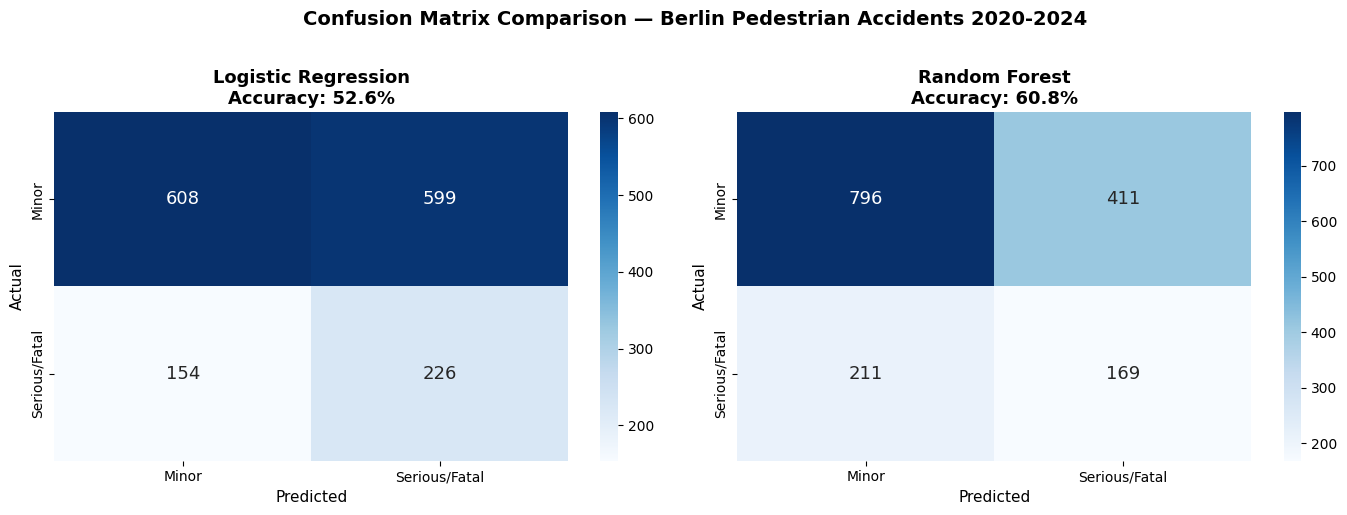

Saved model_confusion_matrices.png


In [ ]:
#  Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Minor', 'Serious/Fatal'],
                yticklabels=['Minor', 'Serious/Fatal'],
                annot_kws={'size': 13})
    ax.set_title(
        f'{title}\nAccuracy: {round(accuracy_score(y_test, y_pred)*100,1)}%',
        fontsize=13, fontweight='bold'
    )
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)

plt.suptitle(
    'Confusion Matrix Comparison — Berlin Pedestrian Accidents 2020-2024',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('model_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved model_confusion_matrices.png')

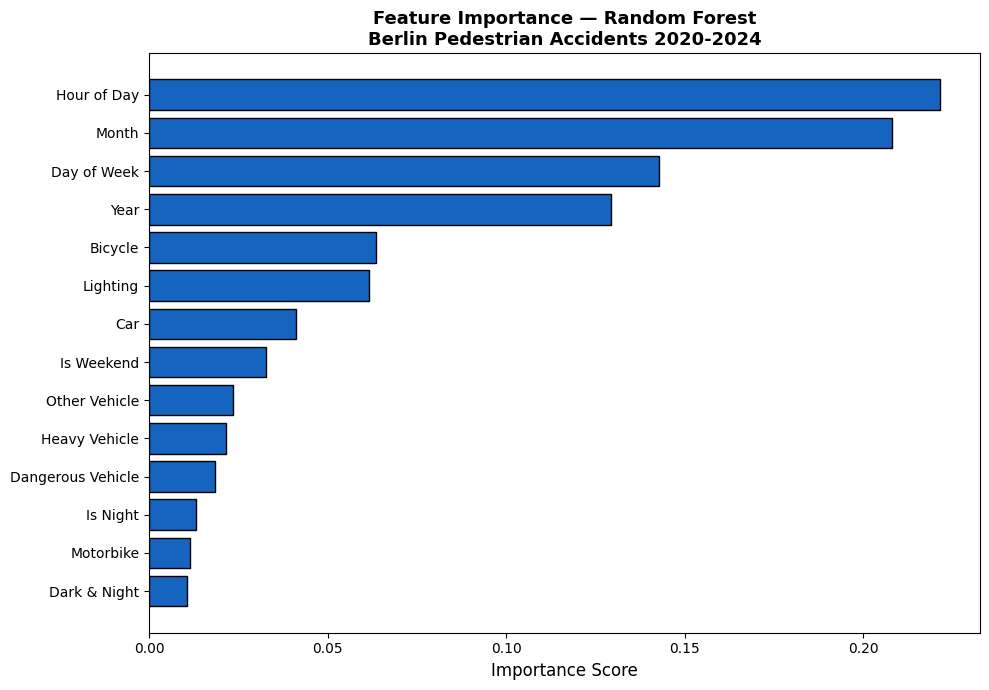

Top features for predicting severity:
  Hour of Day: 22.2%
  Month: 20.8%
  Day of Week: 14.3%
  Year: 12.9%
  Bicycle: 6.4%
  Lighting: 6.2%
  Car: 4.1%
  Is Weekend: 3.3%
  Other Vehicle: 2.3%
  Heavy Vehicle: 2.2%
  Dangerous Vehicle: 1.8%
  Is Night: 1.3%
  Motorbike: 1.1%
  Dark & Night: 1.1%


In [ ]:
#  Random Forest Feature Importance
feature_names_clean = [
    'Lighting', 'Day of Week', 'Hour of Day', 'Month',
    'Car', 'Bicycle', 'Motorbike', 'Heavy Vehicle',
    'Other Vehicle', 'Year',
    'Is Night', 'Is Weekend', 'Dangerous Vehicle', 'Dark & Night'
]

importances = rf.feature_importances_
sorted_idx  = importances.argsort()

plt.figure(figsize=(10, 7))
plt.barh(
    [feature_names_clean[i] for i in sorted_idx],
    importances[sorted_idx],
    color='#1565c0',
    edgecolor='black'
)
plt.title(
    'Feature Importance — Random Forest\nBerlin Pedestrian Accidents 2020-2024',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('model_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top features for predicting severity:')
for i in sorted_idx[::-1]:
    print(f'  {feature_names_clean[i]}: {round(importances[i]*100,1)}%')